<a href="https://colab.research.google.com/github/pireszx/cienciaDeDados/blob/main/exerc_aula_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

caminho = '/content/drive/MyDrive/Ciência de Dados/Arquivos Tabela_2_Nivel_de_instrucao.xlsx'
arquivo = pd.read_excel(caminho)


/tmp/ipykernel_27883/733388267.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


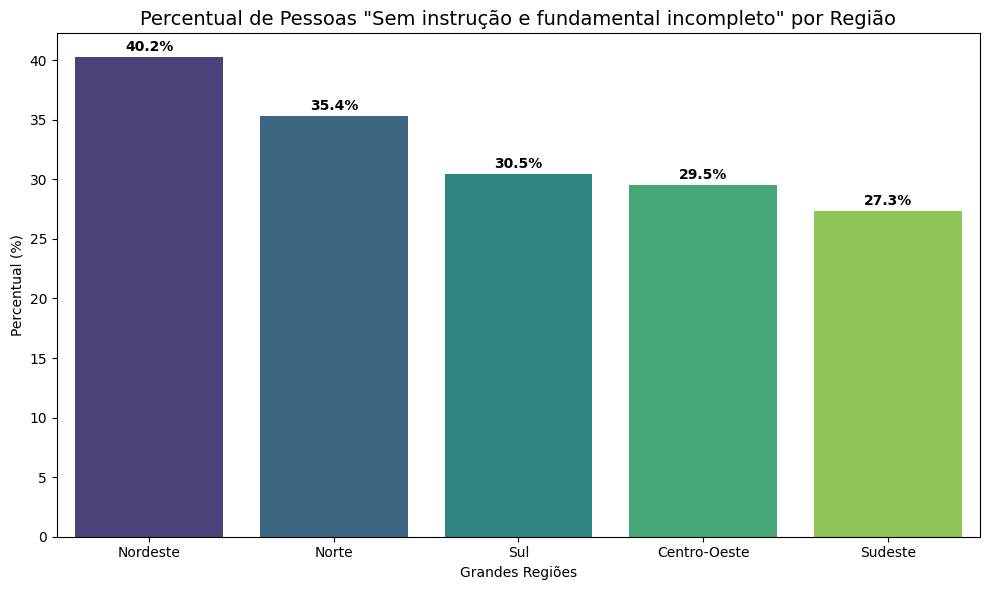

In [ ]:
# 1. Ajuste inicial: Pular as linhas de cabeçalho do IBGE para ler as colunas corretamente
# A Tabela 2 de percentuais começa a ser legível a partir da linha 2 (skiprows=2)
df_instrucao = pd.read_excel(caminho, skiprows=2)

# 2. Renomear a primeira coluna para facilitar o acesso
df_instrucao.rename(columns={df_instrucao.columns[0]: 'Localidade'}, inplace=True)

# 3. FATIAMENTO: Isolar apenas as 5 Grandes Regiões
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
df_regioes = df_instrucao[df_instrucao['Localidade'].isin(regioes)].copy()

# 4. ISOLAR A MÉTRICA: "Sem instrução e fundamental incompleto" (Coluna de índice 1)
# Criamos um DataFrame enxuto para o gráfico
df_comparativo = df_regioes[['Localidade', df_regioes.columns[1]]].copy()
coluna_percentual = df_regioes.columns[1]

# 5. ORDENAR os dados (Opcional, mas ajuda a identificar o maior rapidamente)
df_comparativo = df_comparativo.sort_values(by=coluna_percentual, ascending=False)

# 6. GERAR O GRÁFICO DE BARRAS
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_comparativo,
    x='Localidade',
    y=coluna_percentual,
    palette='viridis'
)

# 7. CUSTOMIZAÇÃO
plt.title('Percentual de Pessoas "Sem instrução e fundamental incompleto" por Região', fontsize=14)
plt.ylabel('Percentual (%)')
plt.xlabel('Grandes Regiões')

# Adicionar o valor exato no topo de cada barra para facilitar a identificação
for i, valor in enumerate(df_comparativo[coluna_percentual]):
    plt.text(i, valor + 0.5, f'{valor:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

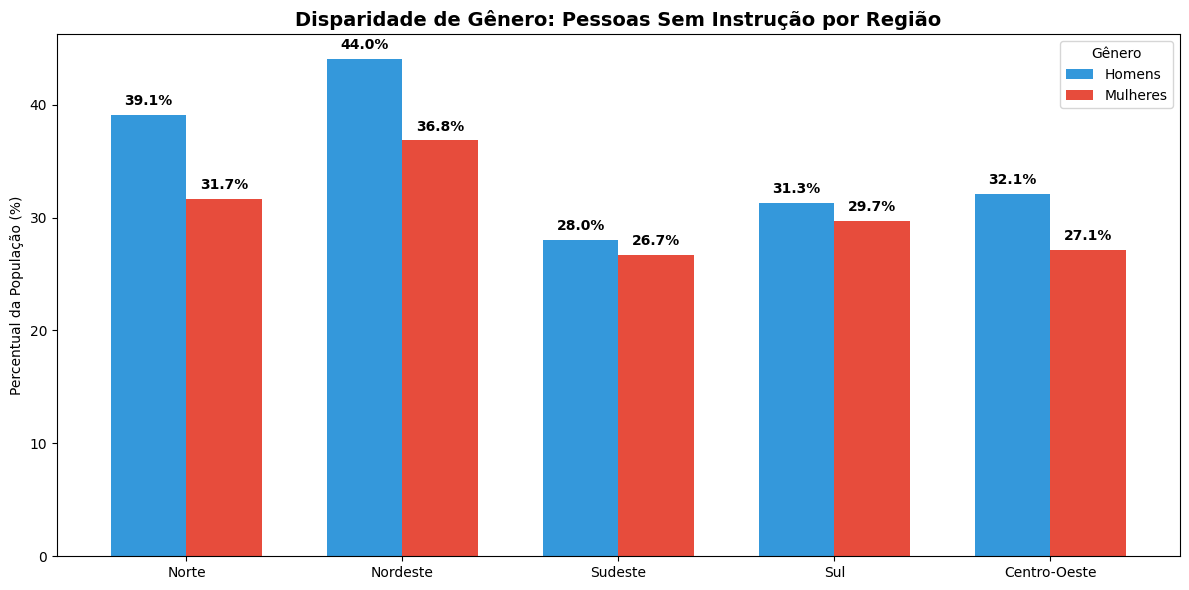

In [4]:
# 1. Carregar os dados
arquivo_perc = pd.read_excel(caminho, skiprows=2)
arquivo_perc.rename(columns={arquivo_perc.columns[0]: 'Localidade'}, inplace=True)

# 2. Lista das regiões para filtrar e ordenar
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
df_regioes = arquivo_perc[arquivo_perc['Localidade'].isin(regioes)].copy()

# 3. Extrair os dados de "Sem instrução e fundamental incompleto"
# Índice 5 = Percentual de Homens nesta categoria
# Índice 9 = Percentual de Mulheres nesta categoria
df_plot = pd.DataFrame({
    'Região': df_regioes['Localidade'],
    'Homens': pd.to_numeric(df_regioes.iloc[:, 5]),
    'Mulheres': pd.to_numeric(df_regioes.iloc[:, 9])
})

# 4. Preparar para o gráfico (Transformar a Região no índice da tabela)
df_plot.set_index('Região', inplace=True)
df_plot = df_plot.reindex(regioes)

# 5. PLOTAR O GRÁFICO DE BARRAS AGRUPADAS
plt.figure(figsize=(12, 6))

ax = df_plot.plot(
    kind='bar',
    figsize=(12, 6),
    color=['#3498db', '#e74c3c'],
    width=0.7
)

# 6. Estética e Títulos
plt.title('Disparidade de Gênero: Pessoas Sem Instrução por Região', fontsize=14, fontweight='bold')
plt.ylabel('Percentual da População (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Gênero')

# 7. Adicionar os valores em cima de CADA barra
for p in ax.patches:
    v = p.get_height()
    if v > 0:
        ax.annotate(f'{v:.1f}%',
                    (p.get_x() + p.get_width() / 2., v),
                    ha='center', va='bottom',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

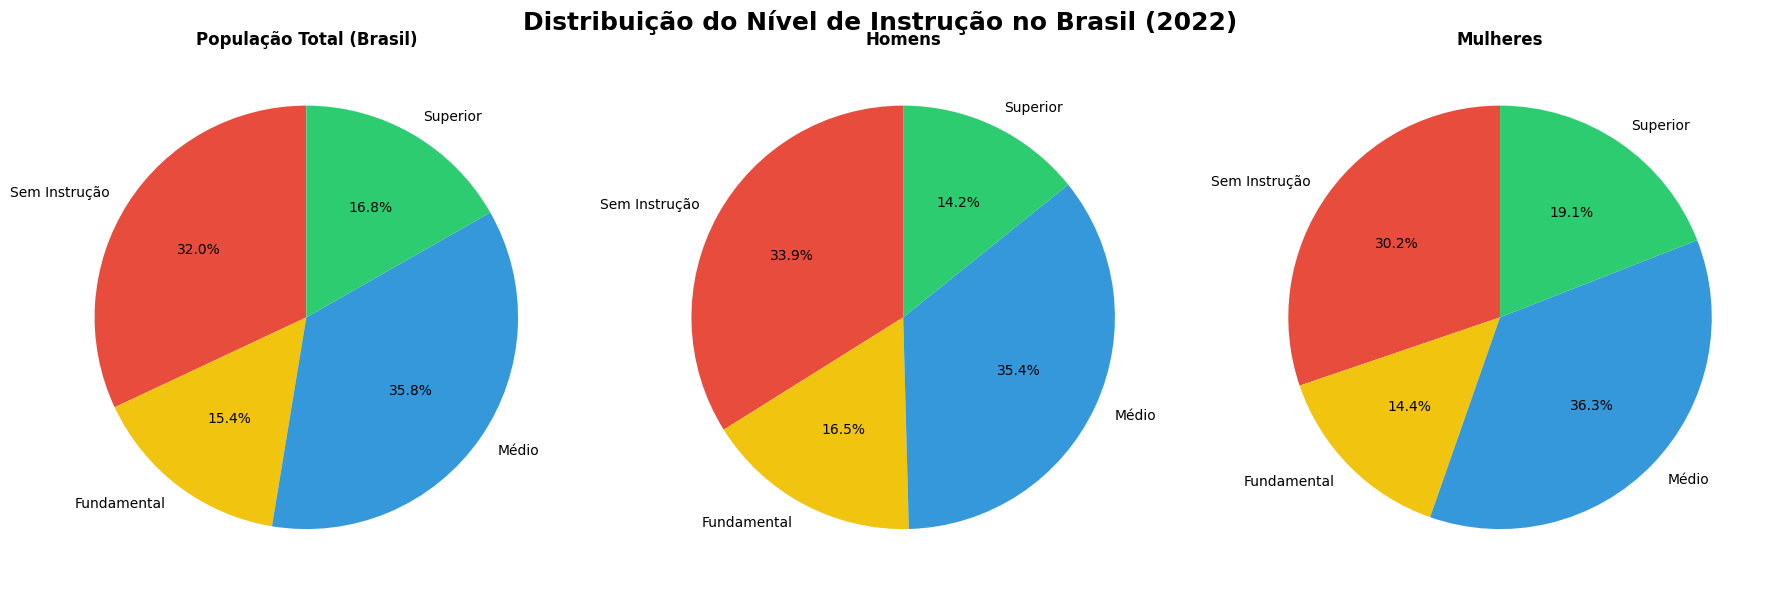

In [5]:
# 1. Isolar a linha do Brasil
df_brasil = arquivo_perc[arquivo_perc['Localidade'] == 'Brasil'].copy()

# 2. Extrair os valores exatos para as três categorias
# .values no final transforma a extração numa lista simples de números
valores_total = pd.to_numeric(df_brasil.iloc[0, 1:5]).values
valores_homens = pd.to_numeric(df_brasil.iloc[0, 5:9]).values
valores_mulheres = pd.to_numeric(df_brasil.iloc[0, 9:13]).values

# Nomes mais curtos para as categorias caberem bem no gráfico
categorias = ['Sem Instrução', 'Fundamental', 'Médio', 'Superior']

# Definir uma paleta de cores padrão para usar nas 3 pizzas
cores = ['#e74c3c', '#f1c40f', '#3498db', '#2ecc71']

# 3. CRIAR O "MOLDURA" PARA OS 3 GRÁFICOS (SUBPLOTS)
# 1 = uma linha de gráficos; 3 = três colunas (lado a lado)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4. Desenhar a Pizza 1 (Total) no primeiro espaço (axes[0])
axes[0].pie(valores_total, labels=categorias, autopct='%1.1f%%', startangle=90, colors=cores)
axes[0].set_title('População Total (Brasil)', fontweight='bold')

# 5. Desenhar a Pizza 2 (Homens) no segundo espaço (axes[1])
axes[1].pie(valores_homens, labels=categorias, autopct='%1.1f%%', startangle=90, colors=cores)
axes[1].set_title('Homens', fontweight='bold')

# 6. Desenhar a Pizza 3 (Mulheres) no terceiro espaço (axes[2])
axes[2].pie(valores_mulheres, labels=categorias, autopct='%1.1f%%', startangle=90, colors=cores)
axes[2].set_title('Mulheres', fontweight='bold')

# 7. Estética final
fig.suptitle('Distribuição do Nível de Instrução no Brasil (2022)', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

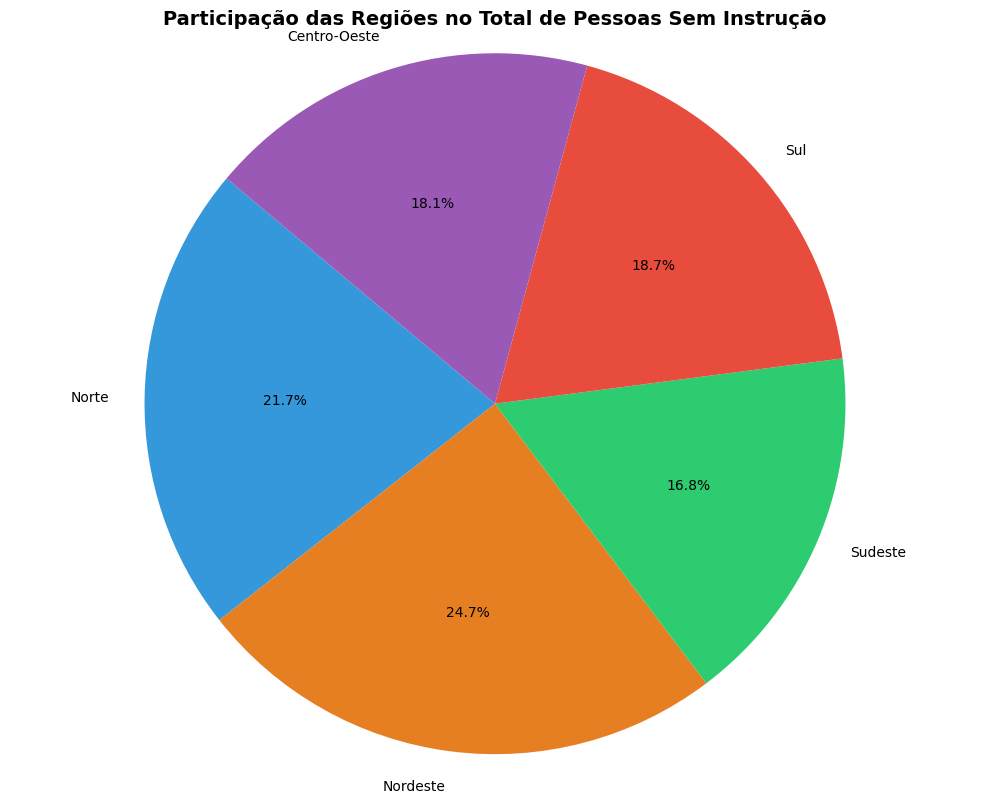

In [9]:
# 1. Extração dos dados de "Sem instrução" (Total da Região - Índice 1)
df_pizza = pd.DataFrame({
    'Regiao': df_regioes['Localidade'],
    'Valor': pd.to_numeric(df_regioes.iloc[:, 1])
})

# 2. Configuração das Cores e Destaque
cores = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c', '#9b59b6']
# Vamos "explodir" (afastar) a maior fatia para dar destaque
explode = (0, 0.1, 0, 0, 0)

# 3. Pizza
plt.figure(figsize=(10, 8))
plt.pie(
    df_pizza['Valor'],
    labels=df_pizza['Regiao'],
    autopct='%1.1f%%',
    startangle=140,
    colors=cores
)

# 4. Título e Ajustes Finais
plt.title('Participação das Regiões no Total de Pessoas Sem Instrução', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

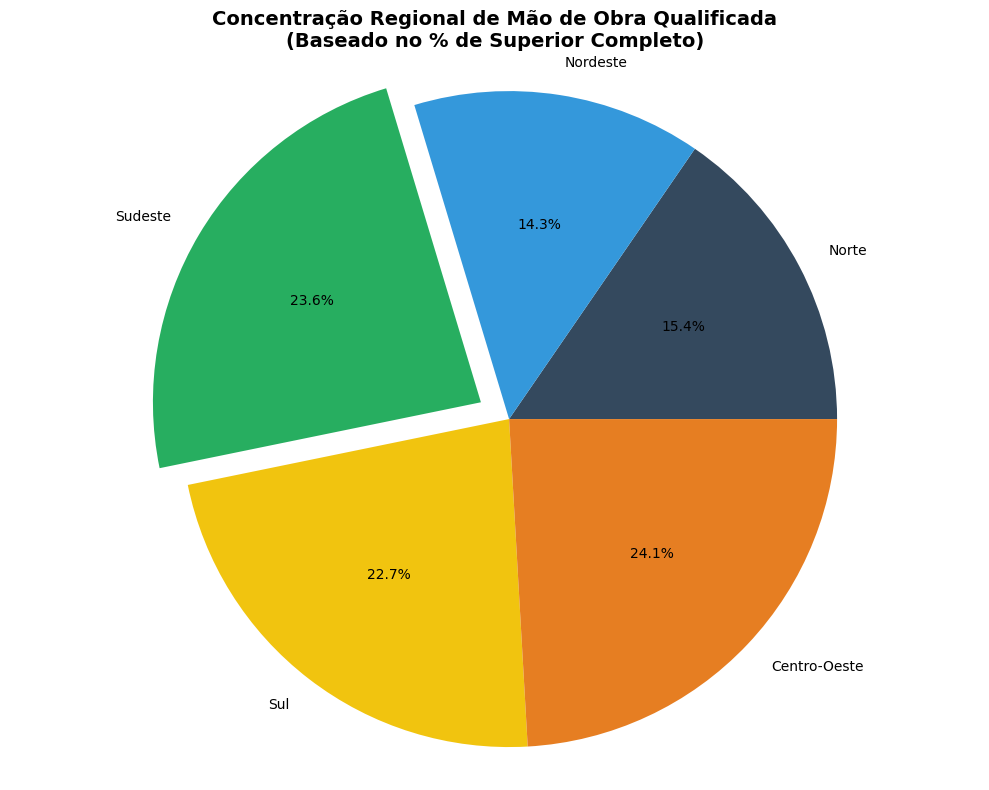

In [12]:
# 1. Filtrar as 5 Grandes Regiões
regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
df_regioes = arquivo_perc[arquivo_perc['Localidade'].isin(regioes)].copy()

# 2. Extrair os dados de "Superior completo" (Coluna de índice 4)
df_superior = pd.DataFrame({
    'Região': df_regioes['Localidade'],
    'Percentual': pd.to_numeric(df_regioes.iloc[:, 4])
})

# 3. Configuração visual
# Cores sólidas para identificar bem os polos
cores_polos = ['#34495e', '#3498db', '#27ae60', '#f1c40f', '#e67e22']

# Vamos destacar (explode) a região que costuma ter o maior percentual
# Geralmente é o Sudeste ou Centro-Oeste/DF. Vamos destacar o Sudeste.
explode = (0, 0, 0.1, 0, 0)

# 4. Gerar o gráfico
plt.figure(figsize=(10, 8))
plt.pie(
    df_superior['Percentual'],
    labels=df_superior['Região'],
    autopct='%1.1f%%',
    colors=cores_polos,
    explode=explode
)

# 5. Título e Legenda
plt.title('Concentração Regional de Mão de Obra Qualificada\n(Baseado no % de Superior Completo)',
          fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

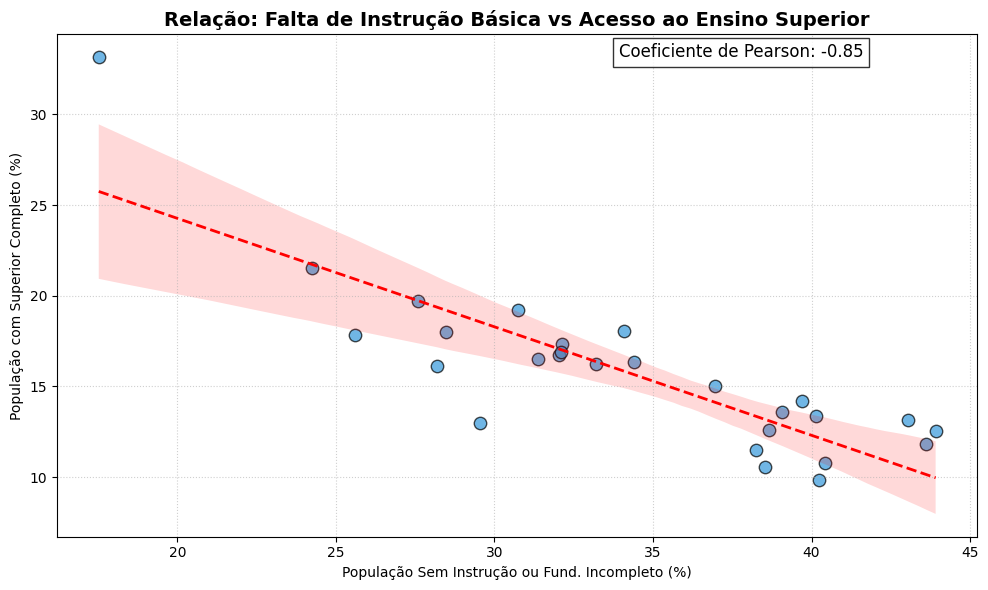

O Coeficiente de Correlação de Pearson é: -0.8476


In [22]:
# 1. Filtrar apenas os estados
df_estados = arquivo_perc[arquivo_perc['Localidade'].isin(lista_estados)].copy()

# 2. Criar a tabela com o Eixo X e o Eixo Y
# Índice 1: Sem instrução / Índice 4: Superior completo
df_scatter = pd.DataFrame({
    'Estado': df_estados['Localidade'],
    'Sem_Instrucao': pd.to_numeric(df_estados.iloc[:, 1]),
    'Superior_Comp': pd.to_numeric(df_estados.iloc[:, 4])
})

# 3. CALCULAR O COEFICIENTE DE PEARSON
# O Pandas tem a função .corr() que faz esse cálculo automaticamente
correlacao = df_scatter['Sem_Instrucao'].corr(df_scatter['Superior_Comp'])

# 4. GERAR O GRÁFICO DE DISPERSÃO
plt.figure(figsize=(10, 6))

# Usamos sns.regplot pois ele desenha os pontos E uma linha de tendência
sns.regplot(
    data=df_scatter,
    x='Sem_Instrucao',
    y='Superior_Comp',
    scatter_kws={'s': 80, 'alpha': 0.7, 'color': '#3498db', 'edgecolor': 'black'},
    line_kws={'color': 'red', 'linewidth': 2, 'linestyle': '--'}
)

# 6. Estética e Anotações
plt.title('Relação: Falta de Instrução Básica vs Acesso ao Ensino Superior', fontsize=14, fontweight='bold')
plt.xlabel('População Sem Instrução ou Fund. Incompleto (%)')
plt.ylabel('População com Superior Completo (%)')

# Adicionamos uma caixa de texto no gráfico com o valor da correlação
texto_corr = f'Coeficiente de Pearson: {correlacao:.2f}'
plt.text(df_scatter['Sem_Instrucao'].max() - 10, df_scatter['Superior_Comp'].max(),
         texto_corr, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Imprimir o resultado no terminal também
print(f"O Coeficiente de Correlação de Pearson é: {correlacao:.4f}")